## Simulation

Small notebook to run the simulation and see what is happening

### Local magnetization

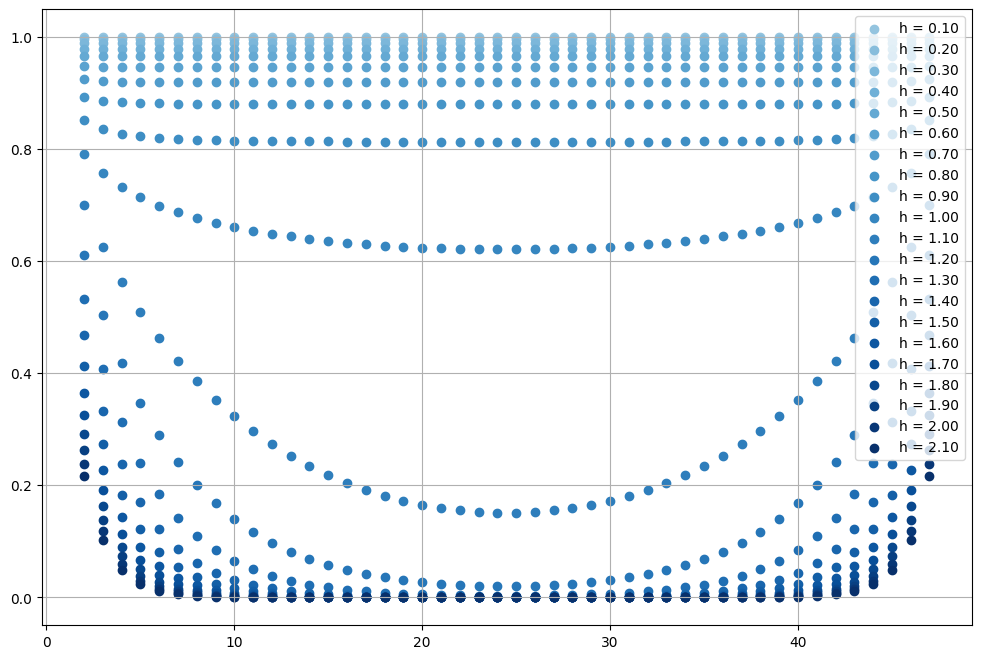

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

outputs = os.path.join(os.getcwd(), "OUT")
cor = cm.Blues(np.linspace(0.4, 1, 21))
values = []
h_indices = []
plt.figure(figsize=(12, 8))

for index, h_value in enumerate(sorted(os.listdir(outputs))):
    result = os.path.join(outputs, h_value)

    arr = np.loadtxt(os.path.join(result, "Z.txt"))
    arr = arr.T
    values.append(min(arr[1]))
    h_indices.append(h_value.split("_")[1])
    plt.scatter(arr[0], arr[1], color=cor[index], label=f"h = {h_value.split("_")[1]}")


plt.legend(loc="upper right")
plt.grid()
plt.show()


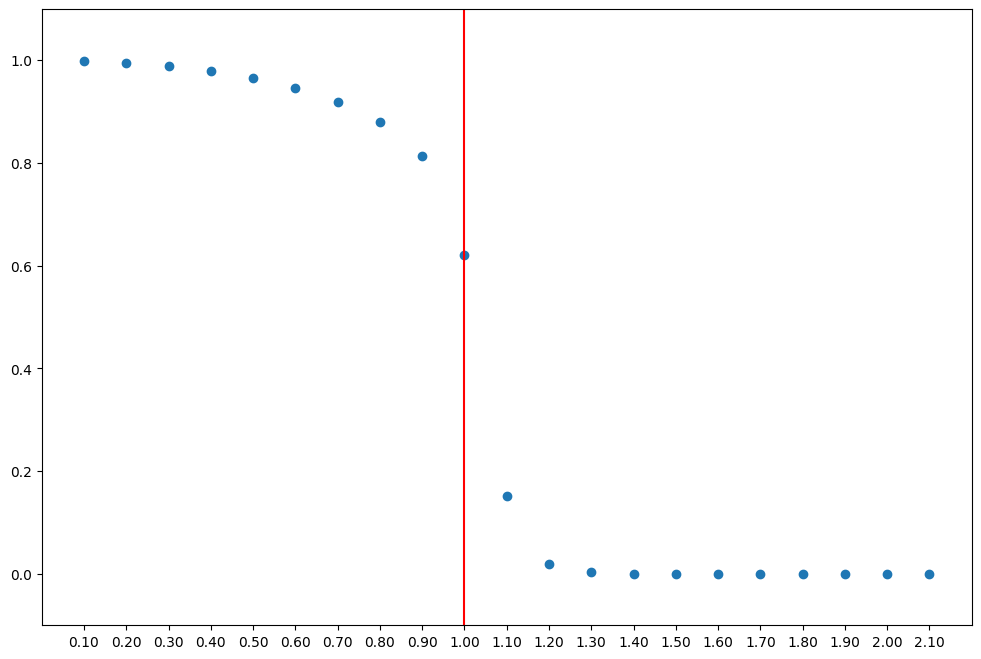

In [37]:
plt.figure(figsize=(12, 8))
plt.scatter(h_indices, values, label="L = 50")
plt.ylim((min(values)-.1, max(values)+.1))
plt.vlines(9, min(values)-.1, max(values)+.1, colors='red')

### Now onto the real Hamiltonian

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
home = os.getcwd()
os.chdir("..")
dir = os.path.join(os.getcwd(), "OUT/First Run")

# extract data
results = np.zeros((6, 21))
for ind, file in enumerate(os.listdir(dir)):
    name = file.split("_")
    h = float(name[1])
    k = float(name[2])

    loc = os.path.join(dir, file)
    magnetization = np.loadtxt(os.path.join(loc, "Z.txt")).T

    results[int((h - 1)*5)][int((k + 2))*5] = min(magnetization[1])

# reset the home directory after each run
os.chdir(home)

TypeError: only length-1 arrays can be converted to Python scalars

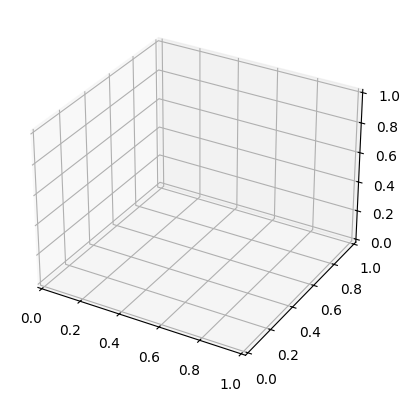

In [7]:
def fun(X, Y):
    return magnetization[int((X - 1) * 5)][int((Y + 2)*5)]

fig = plt.figure()
ax = plt.axes(projection="3d")
# ax.plot3D(np.arange(0, 1.1, 0.2), np.arange(-2, 2.1, 0.2))
# print(len(np.arange(1, 2.1, 0.2)))
# print(len(np.arange(-2, 2.1, 0.2)))
X, Y = np.meshgrid(np.arange(1, 2.1, 0.2), np.arange(-2, 2.1, 0.2))
Z = fun(X, Y)
ax.plot3D(X, Y, Z)
plt.show()